In [1]:
import mg5qs_imports as qs
from pathlib import Path
import os

### Overcoming noise; batch runs

MadGraph suggest for users to keep the size of any particular run under 100k events. A simular limitation also exists on the output size, where 100k event .hepmc files can exceed 50gb, not very friendly. 

To address these limitations, mg5qs is designed to eaysially facilatate batched runs. For example, if you require 1M events, you can run 100x10k. Some addational advantages are: showering these events in parallel, and reducing size of output structure by sevral orders of magnatude. 

This example includes:
- changeing run parameters
- parallelizing shower
- loading and concatenating batch results
- loading results generated elsewhere

### Produce MadGraph framework

Note we are using a proc_card specific to this example. 

In [2]:
INPUT_PATH = Path.cwd()/'input' # madgraph cards
output_name, FRAMEWORK_PATH = qs.run_MG5(INPUT_PATH, proc_card_name='proc_card_batch.dat')

starting process...
done


### Modify run_card

Find the line which by default reads **10000 = nevents** and remove a zero, so it reads **1000 = nevents**. Now **IMPORTANT** scroll to the bottom of the card and hit the **Save** button. mg5qs will only change the underlying file once save is pressed.

In [ ]:
qs.edit_card(FRAMEWORK_PATH)

### Generate 10 LHEs

Now that we are configured for 1k events, we can generate and shower 10 LHEs. This should produce the same number of taus as the prior example, but showing will be parallelized.

In [4]:
RUNS = 10
# can capture card outside of the loop since it will not change 
card = qs.ParamCard(FRAMEWORK_PATH)
for n in range(RUNS):
    qs.generate_LHE(card, FRAMEWORK_PATH)
    print('Generated LHE', n)

Generated LHE 0
Generated LHE 1
Generated LHE 2
Generated LHE 3
Generated LHE 4
Generated LHE 5
Generated LHE 6
Generated LHE 7
Generated LHE 8
Generated LHE 9


In [5]:
LHEs = qs.get_LHEs(FRAMEWORK_PATH)
LHEs

[PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_03/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_05/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_06/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_09/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_07/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_04/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_08/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_10/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_01/unweighted_events.lhe'),
 PosixPath('/home/leo/output/EXAMPLE_BATCH/Events/run_02/unweighted_events.lhe')]

Notice that the LHEs are out of order. This will become important in the next example where they contain diffrent physical parameters. However, for now, all LHEs are iid, so ordering is not important.

### Shower in parallel 

10 LHEs is convinient for my local envronment because I have 12 CPU threads. This means showering takes $\frac{1}{10}$ as long as in the first example for the same total number of events. 

In [6]:
tau_id = 15
qs.pythia_parallel([tau_id], FRAMEWORK_PATH, 'EXAMPLE_BATCH', topics='P_mu', size=10000)

showering: /home/leo/output/EXAMPLE_BATCH/Events/run_07/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_05/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_03/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_06/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_04/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_08/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_09/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_01/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_10/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE_BATCH/Events/run_02/unweighted_events.lhe 

finished showering 10 LHE files


### Load and concatenate results

Since the runs are iid, we set the **concat** argument to **True**. This is the deafult setting, but is done explicitly for clarity.

This will make the data handleing identitical to last example. We capture two return values: the first is the run parameters (selected from any run, at random); the second is the dataframe. The objects being concatenated are dataframes from each run. 

In [7]:
param, df_batch = qs.unpickle('EXAMPLE_BATCH', concat=True)

### Load results from prior example and compare $p_T$ distributions

We expect the distributions to simular since we ran the same process for the same total number of events. 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

How many $\tau$ particles did we capture in this example?

In [9]:
df_batch[np.abs(df_batch['ID'])==tau_id].shape # num rows = num particles

(448, 11)

Unpickle results from before.

In [10]:
param, df_example1 = qs.unpickle('EXAMPLE')
df_example1.shape

(41064, 11)

Uh oh, last time when showering, we captured $\tau$ **and** $e^-$, but we're not intrested in the electrons this time. So, we need to construct a new dataframe from the existing one that only contains paticles with ID = tau_id.

In [11]:
df_taus=df_example1[np.abs(df_example1['ID'])==tau_id].copy()
df_taus.shape

(493, 11)

That looks better, now we have simular number of $\tau$ particles. 

One final complecation: notice the **.copy()** above. This is because we now want to edit **df_taus** by adding a new column. When constructing a dataframe out of a diffrent, preexisting data frame (as done above), pandas will create a referance to the origional. This referance does not have its own memory allocation, so any attempt to make changes will fail. Thus, we must explicitly instruct pandas to allocate new memory. 

Though this is a limitation of pandas, not mg5qs, it is worth mentioning because it is encountered often. 

Now, we are ready to compute $p_T$ for both dataframes. (Math omited to reduce fear, see example 1.)

In [12]:
df_batch['pT'] = np.sqrt((df_batch['px']**2)+(df_batch['py']**2))
df_taus['pT'] = np.sqrt((df_taus['px']**2)+(df_taus['py']**2))

### Plot results

Again, any plotting library will do. I will continue to use matplotlib. 

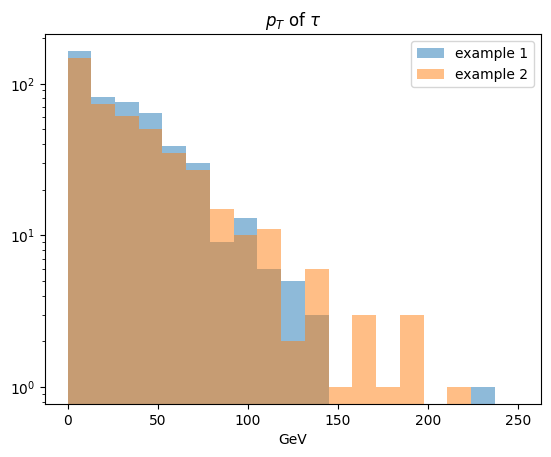

In [13]:
bins = np.linspace(0, 250, 20)
plt.hist(df_taus['pT'], bins=bins, label='example 1', alpha=.5)
plt.hist(df_batch['pT'], bins=bins, label='example 2', alpha=.5)
plt.yscale('log')
plt.title(f'$p_T$ of $\\tau$')
plt.legend()
plt.xlabel('GeV')
plt.show()